# Notebook 3 — EEG Preprocessing Pipeline

## From raw epochs to classifier-ready features

---

## Section 0 — What we're building on

### Prior knowledge this notebook depends on

From **Notebook 1 (Signal Processing Intuition)**, you already understand:
- Sampling rate, Nyquist theorem, frequency bands (delta/theta/alpha/beta/gamma)
- Band-pass filtering with `filtfilt`, Welch PSD, spectrograms
- ERD: event-related desynchronization — when you *imagine* moving your left hand, neurons over the right motor cortex (around C4) become *desynchronized*, suppressing alpha/beta power. This is the physiological signal we're trying to classify.

From **Notebook 2 (EEG Data Exploration)**, you already understand:
- MNE `Raw` and `Epochs` objects, GDF loading, channel renaming, montage setup
- Band-pass filtering and average referencing on MNE objects
- `epochs.get_data()` returns shape `(n_trials, n_channels, n_times)`
- Event codes: 769=left hand, 770=right hand, 771=feet, 772=tongue
- Contralateral ERD pattern: left hand imagery → C4 alpha suppression, right hand → C3

### What this notebook adds

In Notebook 2, you loaded and visualized clean-looking data. But real EEG is **noisy** — eye blinks, muscle movements, and electrode pops produce artifacts that dwarf the neural signals we care about. A classifier trained on raw epochs will learn to classify artifacts, not brain states.

This notebook builds a complete preprocessing pipeline that:

1. **Detects and rejects artifact-contaminated trials** — removing epochs where the signal exceeds physiological limits
2. **Splits data at the epoch level** before any further processing — preventing data leakage
3. **Applies CSP spatial filtering** — projecting multichannel EEG into components that maximally distinguish motor imagery classes
4. **Segments epochs into sliding windows** — creating more training samples from each trial
5. **Normalizes features** using only training statistics — preventing information from the test set leaking into training

The final product is `run_pipeline()` — a single function that takes a subject ID and returns `X_train, X_test, y_train, y_test` ready for any classifier. Every subsequent notebook in this series will start by calling this function.

> **Why does this matter for deployed BCI systems?** In a real-time BCI, you can't go back and clean the data manually. The preprocessing pipeline *is* part of the system — it runs on every incoming epoch. Design decisions here (threshold levels, window size, normalization strategy) directly affect whether a wheelchair user can reliably control their device. Getting this right is as important as model architecture.

---
## Setup

In [2]:
import torch

if torch.backends.mps.is_available():
    DEVICE = torch.device('mps')
elif torch.cuda.is_available():
    DEVICE = torch.device('cuda')
else:
    DEVICE = torch.device('cpu')

print(f"Using device: {DEVICE}")

Using device: mps


In [3]:
import numpy as np
import mne
from scipy.io import loadmat
from sklearn.model_selection import StratifiedShuffleSplit
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore', category=RuntimeWarning)
mne.set_log_level('WARNING')

# === CONFIGURE THIS PATH ===
# Point to the directory containing A01T.gdf, A01E.gdf, etc.
DATA_DIR = '../mne_data/bci_iv_2a/'

# Dataset constants
FS = 250          # Sampling rate (Hz)
N_CHANNELS = 22   # EEG channels (after dropping EOG)
N_CLASSES = 4      # left hand, right hand, feet, tongue
EVENT_IDS = {'left_hand': 769, 'right_hand': 770, 'feet': 771, 'tongue': 772}

# Channel names for the 22 EEG channels in Dataset 2a
CH_NAMES_22 = [
    'Fz', 'FC3', 'FC1', 'FCz', 'FC2', 'FC4',
    'C5', 'C3', 'C1', 'Cz', 'C2', 'C4', 'C6',
    'CP3', 'CP1', 'CPz', 'CP2', 'CP4',
    'P1', 'Pz', 'P2', 'POz'
]

---
## Part 1 — Loading and Epoching (Review)

This loading function recaps what you built in Notebook 2. It's provided complete since loading is not the focus of this notebook — we need clean epochs to preprocess.

The function:
1. Loads the GDF file with MNE
2. Renames channels to standard 10-20 names
3. Picks only the 22 EEG channels (drops 3 EOG)
4. Applies a 4–38 Hz band-pass filter (captures mu/beta bands relevant to motor imagery, rejects DC drift and high-frequency muscle noise)
5. Applies average reference
6. Extracts epochs from 0.5s to 2.5s after cue onset (2 seconds of motor imagery)
7. Applies baseline correction (subtracts mean of first 0.5s)

For evaluation files (A0xE.gdf), labels come from a separate `.mat` file.

In [4]:
def load_subject_epochs(subject_id, data_dir, session='T'):
    """
    Load and epoch one subject's data from BCI Competition IV Dataset 2a.
    
    Args:
        subject_id: str, e.g. 'A01'
        data_dir:   str, path to directory containing .gdf and .mat files
        session:    str, 'T' for training, 'E' for evaluation
    
    Returns:
        epochs_data: np.ndarray, shape (n_trials, 22, n_times)
        labels:      np.ndarray, shape (n_trials,), values in {0, 1, 2, 3}
                     0=left hand, 1=right hand, 2=feet, 3=tongue
    """
    gdf_path = f"{data_dir}/{subject_id}{session}.gdf"
    raw = mne.io.read_raw_gdf(gdf_path, preload=True)
    
    # Rename channels to standard 10-20 names
    eeg_ch_names = raw.ch_names[:22]
    rename_map = {old: new for old, new in zip(eeg_ch_names, CH_NAMES_22)}
    raw.rename_channels(rename_map)
    
    # Pick only EEG channels
    raw.pick_channels(CH_NAMES_22)
    
    # Set montage for topographic plotting
    montage = mne.channels.make_standard_montage('standard_1020')
    raw.set_montage(montage)
    
    # Band-pass filter: 4-38 Hz
    raw.filter(4.0, 38.0, fir_design='firwin')
    
    # Average reference
    raw.set_eeg_reference('average', projection=False)
    
    # Extract events
    events, event_id_full = mne.events_from_annotations(raw)
    
    # Map to our event IDs — GDF annotations vary by MNE version,
    # so we find the correct annotation keys for codes 769-772
    target_events = {}
    for key, val in event_id_full.items():
        # Try to extract the numeric code from the annotation string
        try:
            code = int(key)
        except ValueError:
            # Some MNE versions use strings like '769', others differ
            continue
        if code in [769, 770, 771, 772]:
            target_events[key] = val
    
    # Create epochs: 0.5s to 2.5s relative to cue onset
    epochs = mne.Epochs(
        raw, events, event_id=target_events,
        tmin=0.5, tmax=2.5,
        baseline=None,  # We'll do baseline correction manually
        preload=True,
        proj=False
    )
    
    epochs_data = epochs.get_data()  # (n_trials, 22, n_times)
    
    # Get labels
    if session == 'T':
        # Training file: labels from events
        event_codes = epochs.events[:, 2]
        # Map MNE event IDs back to original codes
        inv_map = {v: int(k) for k, v in target_events.items()}
        original_codes = np.array([inv_map[c] for c in event_codes])
        labels = original_codes - 769  # 769->0, 770->1, 771->2, 772->3
    else:
        # Evaluation file: labels from .mat file
        mat_path = f"{data_dir}/{subject_id}E.mat"
        mat = loadmat(mat_path)
        labels = mat['classlabel'].flatten() - 1  # 1-indexed to 0-indexed
        # Trim to match number of valid epochs
        labels = labels[:len(epochs_data)]
    
    # Baseline correction: subtract mean of first 125 samples (0.5s)
    baseline = epochs_data[:, :, :125].mean(axis=2, keepdims=True)
    epochs_data = epochs_data - baseline
    
    print(f"  {subject_id}{session}: {epochs_data.shape[0]} epochs, "
          f"shape {epochs_data.shape}, "
          f"class dist: {np.bincount(labels)}")
    
    return epochs_data, labels

In [5]:
# Quick test: load one subject
test_data, test_labels = load_subject_epochs('A01', DATA_DIR, session='T')
print(f"\nData shape: {test_data.shape}")
print(f"Labels shape: {test_labels.shape}")
print(f"Label values: {np.unique(test_labels)}")
print(f"Samples per class: {np.bincount(test_labels)}")

  A01T: 288 epochs, shape (288, 22, 501), class dist: [72 72 72 72]

Data shape: (288, 22, 501)
Labels shape: (288,)
Label values: [0 1 2 3]
Samples per class: [72 72 72 72]


In [6]:
data, labels = load_subject_epochs('A01', DATA_DIR, session='T')
ptp = np.ptp(data, axis=2).max(axis=1) * 1e6
print(f"max PTP: {ptp.max():.1f} µV")
print(f"mean PTP: {ptp.mean():.1f} µV")
print(f"trials > 100µV: {(ptp > 100).sum()}")

  A01T: 288 epochs, shape (288, 22, 501), class dist: [72 72 72 72]
max PTP: 69.1 µV
mean PTP: 28.8 µV
trials > 100µV: 0


---
## Part 2 — Artifact Detection and Rejection

### What are artifacts and why must we remove them?

EEG measures voltage differences on the order of **microvolts** (µV). Brain signals during motor imagery are typically 5–50 µV. But many non-neural events produce much larger voltages:

| Source | Typical amplitude | Cause |
|---|---|---|
| Eye blink | 100–300 µV | Cornea-retina dipole moves when eyelid closes |
| Eye movement | 50–200 µV | EOG artifact propagates to frontal channels |
| Muscle (EMG) | 10–100 µV | Jaw clench, neck tension — broadband contamination |
| Electrode pop | >500 µV | Sudden impedance change at the electrode-skin interface |

If we leave these in, the classifier may learn to distinguish "subject blinked during left hand imagery" rather than actual motor cortex activation patterns. This would fail catastrophically in deployment because blink timing is random.

### Peak-to-peak thresholding

The simplest and most robust artifact detection method is **peak-to-peak (PTP) thresholding**:

$$\text{PTP}_{\text{trial}, \text{channel}} = \max_t\, x(t) - \min_t\, x(t)$$

For each trial and each channel, compute the difference between the maximum and minimum voltage across all timepoints. If **any channel** in a trial exceeds a threshold, the entire trial is rejected.

**Threshold choice:** A common value is **100 µV**. This is roughly 2× the expected maximum amplitude of normal EEG after band-pass filtering. Too low → you reject good trials and lose training data. Too high → you let artifacts through. For Dataset 2a (already band-pass filtered to 4–38 Hz, which removes a lot of EOG content), 100 µV is a reasonable starting point.

> **Why peak-to-peak instead of amplitude thresholding?** Pure amplitude thresholding (reject if `|x| > threshold`) fails when the signal has a DC offset or slow drift. PTP measures the *range* within each epoch, making it invariant to baseline shifts. In a deployed BCI, electrode impedance can drift over a session — PTP handles this gracefully.

### Critical: artifact rejection must remove labels too

When you reject trial index 47, you must also remove `labels[47]`. The data array and label array must stay aligned. This seems obvious, but it's a common bug — especially when boolean indexing is involved.

---

### Task: Implement `detect_artifacts()`

**Function specification:**

```
detect_artifacts(epochs_data, threshold_uv=100.0)

Args:
    epochs_data:  np.ndarray, shape (n_trials, n_channels, n_times)
                  EEG data in microvolts
    threshold_uv: float, peak-to-peak threshold in µV

Returns:
    clean_mask: np.ndarray, shape (n_trials,), dtype=bool
               True for clean trials, False for artifact trials
```

**Pseudocode:**
1. For each trial, compute PTP across timepoints (axis=2) for every channel → shape `(n_trials, n_channels)`
2. For each trial, take the max PTP across channels → shape `(n_trials,)`
3. A trial is clean if its max PTP ≤ threshold

In [7]:
def detect_artifacts(epochs_data, threshold_uv=100.0):
    """
    Detect artifact-contaminated trials using peak-to-peak thresholding.
    
    Args:
        epochs_data:  np.ndarray, shape (n_trials, n_channels, n_times)
        threshold_uv: float, PTP threshold in microvolts
    
    Returns:
        clean_mask: np.ndarray, shape (n_trials,), dtype=bool
                    True = clean, False = artifact
    """
    # YOUR CODE HERE
    # mask = []
    # n_trials, n_channels, n_times = epochs_data.shape
    # for i in range(n_trials):
    #     clean = True
    #     for j in range(n_channels):
    #         if np.max(epochs_data[i,j,:]) - np.min(epochs_data[i,j,:]) >threshold_uv:
    #             clean = False
    #             break
    #     mask.append(clean)
    # return np.array(mask)
    ptp_per_channel = np.max(epochs_data, axis=2) - np.min(epochs_data, axis=2)
    max_ptp_per_trial = np.max(ptp_per_channel, axis=1) *1e6
    clean_mask = max_ptp_per_trial <= threshold_uv
    return clean_mask

In [8]:
# Sanity check — detect_artifacts
_mask = detect_artifacts(test_data, threshold_uv=100.0)

assert _mask.shape == (test_data.shape[0],), f"Expected shape ({test_data.shape[0]},), got {_mask.shape}"
assert _mask.dtype == bool, f"Expected bool dtype, got {_mask.dtype}"
assert _mask.sum() > 0, "All trials were rejected — threshold may be too low"
#assert _mask.sum() < len(_mask), "No trials were rejected — threshold may be too high, or check your PTP computation"

# Verify: manually check one trial marked as artifact
_artifact_idx = np.where(~_mask)[0]
if len(_artifact_idx) > 0:
    _trial = test_data[_artifact_idx[0]]
    _ptp = _trial.max(axis=1) - _trial.min(axis=1)
    assert _ptp.max() > 100.0, "Artifact trial should have PTP > threshold"

print(f"✓ detect_artifacts: {_mask.sum()}/{len(_mask)} trials clean "
      f"({100*_mask.sum()/len(_mask):.1f}%), {(~_mask).sum()} rejected")

✓ detect_artifacts: 288/288 trials clean (100.0%), 0 rejected


In [9]:
data, labels = load_subject_epochs('A01', DATA_DIR, session='T')
ptp = np.ptp(data, axis=2).max(axis=1) * 1e6
print(f"max PTP: {ptp.max():.1f} µV")
print(f"mean PTP: {ptp.mean():.1f} µV")
print(f"trials > 100µV: {(ptp > 100).sum()}")

  A01T: 288 epochs, shape (288, 22, 501), class dist: [72 72 72 72]
max PTP: 69.1 µV
mean PTP: 28.8 µV
trials > 100µV: 0


### Task: Implement `reject_artifacts()`

This function applies the mask to both data and labels, keeping them aligned.

```
reject_artifacts(epochs_data, labels, threshold_uv=100.0)

Args:
    epochs_data:  np.ndarray, shape (n_trials, n_channels, n_times)
    labels:       np.ndarray, shape (n_trials,)
    threshold_uv: float

Returns:
    clean_data:   np.ndarray, shape (n_clean, n_channels, n_times)
    clean_labels: np.ndarray, shape (n_clean,)
    n_rejected:   int, number of trials rejected
```

**Pseudocode:**
1. Call `detect_artifacts()` to get the boolean mask
2. Apply the mask to both `epochs_data` and `labels` using boolean indexing
3. Return cleaned arrays and the count of rejected trials

In [10]:
def reject_artifacts(epochs_data, labels, threshold_uv=100.0):
    """
    Reject artifact trials and their corresponding labels.
    
    Args:
        epochs_data:  np.ndarray, shape (n_trials, n_channels, n_times)
        labels:       np.ndarray, shape (n_trials,)
        threshold_uv: float, PTP threshold in microvolts
    
    Returns:
        clean_data:   np.ndarray, shape (n_clean, n_channels, n_times)
        clean_labels: np.ndarray, shape (n_clean,)
        n_rejected:   int
    """
    # YOUR CODE HERE
    mask = detect_artifacts(epochs_data,threshold_uv)
    clean_data = epochs_data[mask]
    clean_labels = labels[mask]
    n_rejected = (~mask).sum()
    return clean_data,clean_labels,n_rejected

In [11]:
# Sanity check — reject_artifacts
_clean_data, _clean_labels, _n_rej = reject_artifacts(test_data, test_labels, threshold_uv=60.0)

assert _clean_data.shape[0] == _clean_labels.shape[0], "Data and labels have different lengths!"
assert _clean_data.shape[0] + _n_rej == test_data.shape[0], "Clean + rejected should equal original count"
assert _clean_data.shape[1:] == test_data.shape[1:], "Channel and time dims should be unchanged"

# Check label alignment: the labels of clean trials should match
_mask = detect_artifacts(test_data, threshold_uv=60.0)
assert np.array_equal(_clean_labels, test_labels[_mask]), "Labels not properly aligned with data!"

print(f"✓ reject_artifacts: {_clean_data.shape[0]} clean, {_n_rej} rejected")
print(f"  Class distribution after rejection: {np.bincount(_clean_labels)}")

✓ reject_artifacts: 287 clean, 1 rejected
  Class distribution after rejection: [72 72 72 71]


### Visualize: artifact distribution

Let's see what the PTP distribution looks like and how our threshold divides it.

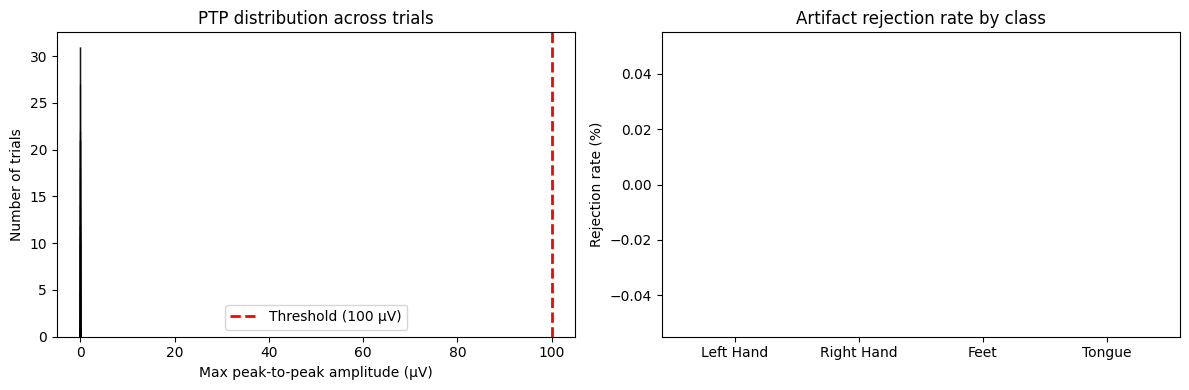


Overall rejection rate: 0.0%


In [12]:
# Visualization: PTP distribution (provided)
ptp_per_trial = np.ptp(test_data,axis=2).max(axis=1)  # max PTP across channels, per trial

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histogram of max PTP
axes[0].hist(ptp_per_trial, bins=50, edgecolor='black', alpha=0.7)
axes[0].axvline(100, color='red', linestyle='--', linewidth=2, label='Threshold (100 µV)')
axes[0].set_xlabel('Max peak-to-peak amplitude (µV)')
axes[0].set_ylabel('Number of trials')
axes[0].set_title('PTP distribution across trials')
axes[0].legend()

# Per-class rejection rates
class_names = ['Left Hand', 'Right Hand', 'Feet', 'Tongue']
mask = detect_artifacts(test_data, 100.0)
rejection_rates = []
for c in range(4):
    class_mask = test_labels == c
    n_total = class_mask.sum()
    n_rejected = (~mask & class_mask).sum()
    rejection_rates.append(100 * n_rejected / n_total)

axes[1].bar(class_names, rejection_rates, color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'])
axes[1].set_ylabel('Rejection rate (%)')
axes[1].set_title('Artifact rejection rate by class')

plt.tight_layout()
plt.show()

print(f"\nOverall rejection rate: {100*(~mask).sum()/len(mask):.1f}%")

> **Decision — Artifact threshold**
>
> 1. Look at your PTP histogram. Is the distribution unimodal or bimodal? What does this tell you about the nature of artifacts in this dataset?
> 2. Are the rejection rates balanced across classes? If feet imagery has a higher rejection rate than hand imagery, why might that be? (Hint: think about what muscles are near the EEG cap.)
> 3. In a deployed BCI, would you prefer a lower threshold (rejecting more trials but keeping cleaner data) or a higher threshold (keeping more trials but allowing some artifacts)? How does this trade-off change if the user can only generate 10 commands per minute?
>
> *Write your answers here.*

---
## Part 3 — Train/Test Splitting (Epoch-Level)

### Why split BEFORE windowing? — Understanding data leakage

This is the single most important design decision in this notebook, and the most common mistake in published BCI papers.

In Part 5, we'll segment each 2-second epoch into overlapping 1-second windows. If we do windowing first and then split randomly, **windows from the same epoch can end up in both train and test sets**. Since overlapping windows share most of their data points, the classifier achieves artificially high test accuracy — it's essentially memorizing the training data it's already seen in a slightly shifted form.

**Concrete example:** Say epoch #42 (2 seconds, 500 samples) produces three 1-second windows at offsets 0, 125, and 250 samples. Windows 1 and 2 share 125 out of 250 samples — 50% overlap. If window 1 is in training and window 2 is in test, the model has already seen half the test sample during training. Published accuracy: 85%. Actual accuracy on new data: 65%.

**The rule:** Split epochs into train and test *first*, then window each set independently. Windows from a single epoch all go to the same split. No exceptions.

### StratifiedShuffleSplit

We use `sklearn.model_selection.StratifiedShuffleSplit` for the split:

```python
sklearn.model_selection.StratifiedShuffleSplit(
    n_splits=1,        # int — number of re-shuffled splits. We just need one.
    test_size=0.2,     # float — fraction held out for test
    random_state=42    # int — for reproducibility
)
```

**"Stratified"** means the class proportions in train and test match the original distribution. If you started with 25% per class, you'll get ~25% per class in both splits. This prevents the pathological case where, by random chance, all "tongue" trials end up in the test set.

**Usage pattern:**
```python
sss = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(sss.split(X, y))  # split() yields (train, test) index arrays
X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]
```

> **Why not just use the training/evaluation split from the competition?** For the final capstone (Notebook 7), we will use A0xT.gdf for training and A0xE.gdf for held-out test — exactly as the competition intended. But for development (Notebooks 3–6), we work only with the training file and create our own train/test split. This gives us faster iteration and prevents us from "peeking" at the held-out set during development. The evaluation files are sacred — we touch them once, at the end.

---

### Task: Implement `split_epochs()`

```
split_epochs(epochs_data, labels, test_size=0.2, random_state=42)

Args:
    epochs_data:  np.ndarray, shape (n_trials, n_channels, n_times)
    labels:       np.ndarray, shape (n_trials,)
    test_size:    float, fraction for test set
    random_state: int, random seed

Returns:
    X_train: np.ndarray, shape (n_train, n_channels, n_times)
    X_test:  np.ndarray, shape (n_test, n_channels, n_times)
    y_train: np.ndarray, shape (n_train,)
    y_test:  np.ndarray, shape (n_test,)
```

**Pseudocode:**
1. Create a `StratifiedShuffleSplit` with `n_splits=1`
2. Call `.split()` and extract train/test indices
3. Index into both data and labels

In [13]:
def split_epochs(epochs_data, labels, test_size=0.2, random_state=42):
    """
    Stratified train/test split at the epoch level.
    
    Args:
        epochs_data:  np.ndarray, shape (n_trials, n_channels, n_times)
        labels:       np.ndarray, shape (n_trials,)
        test_size:    float
        random_state: int
    
    Returns:
        X_train, X_test, y_train, y_test
    """
    # YOUR CODE HERE
    sss = StratifiedShuffleSplit(n_splits=1,test_size=test_size,random_state=random_state)
    train_idx,test_idx = next(sss.split(epochs_data,labels))
    X_train,X_test = epochs_data[train_idx],epochs_data[test_idx]
    y_train,y_test = labels[train_idx],labels[test_idx]
    return X_train, X_test, y_train, y_test

In [14]:
# Sanity check — split_epochs
_X_tr, _X_te, _y_tr, _y_te = split_epochs(_clean_data, _clean_labels)

assert _X_tr.shape[0] == _y_tr.shape[0], "Train data and labels mismatched"
assert _X_te.shape[0] == _y_te.shape[0], "Test data and labels mismatched"
assert _X_tr.shape[0] + _X_te.shape[0] == _clean_data.shape[0], "Total doesn't add up"

# Check stratification: class proportions should be similar
_train_dist = np.bincount(_y_tr) / len(_y_tr)
_test_dist = np.bincount(_y_te) / len(_y_te)
assert np.allclose(_train_dist, _test_dist, atol=0.05), \
    f"Stratification failed: train dist {_train_dist} vs test dist {_test_dist}"

# Check no data leakage: epochs dimensions preserved
assert _X_tr.shape[1:] == _clean_data.shape[1:], "Channel/time dims changed"

print(f"✓ split_epochs: train={_X_tr.shape[0]}, test={_X_te.shape[0]}")
print(f"  Train class dist: {np.bincount(_y_tr)}")
print(f"  Test  class dist: {np.bincount(_y_te)}")

✓ split_epochs: train=229, test=58
  Train class dist: [58 57 57 57]
  Test  class dist: [14 15 15 14]


---
## Part 4 — CSP Spatial Filtering

### What is CSP and why do we need it?

EEG signals are recorded from 22 electrodes, each picking up a mixture of activity from many brain regions. The ERD signal from motor cortex is present at electrodes like C3 and C4, but it's mixed with noise from other sources. **Common Spatial Patterns (CSP)** finds *linear combinations* of channels that maximize the variance difference between two classes.

### The CSP optimization objective

Given two classes of EEG data, CSP solves:

$$\mathbf{w}^* = \arg\max_{\mathbf{w}} \frac{\mathbf{w}^\top \mathbf{\Sigma}_1 \mathbf{w}}{\mathbf{w}^\top \mathbf{\Sigma}_2 \mathbf{w}}$$

where:
- $\mathbf{w} \in \mathbb{R}^{C}$ — a spatial filter (weight vector over $C$ channels)
- $\mathbf{\Sigma}_1 \in \mathbb{R}^{C \times C}$ — average covariance matrix of class 1 trials
- $\mathbf{\Sigma}_2 \in \mathbb{R}^{C \times C}$ — average covariance matrix of class 2 trials

**In plain English:** CSP finds the channel weighting that makes class 1 signals as *variable* as possible while simultaneously making class 2 signals as *constant* as possible. The solution is a generalized eigenvalue problem.

**Physical intuition for motor imagery:** When you imagine moving your left hand, alpha power *decreases* at C4 (contralateral desynchronization). CSP automatically discovers this — one of its top components will be a filter centered on C4 that captures high variance during left-hand imagery and low variance during right-hand imagery.

### CSP for multi-class: One-vs-Rest

The optimization above is inherently two-class. For our 4-class problem, MNE's CSP implementation uses a **One-vs-Rest (OVR)** strategy: it computes CSP filters for (left hand vs rest), (right hand vs rest), (feet vs rest), and (tongue vs rest), then concatenates the top components from each. With `n_components=4`, you get 4 filters for each of the 4 binary problems = 16 total components. MNE handles this internally.

### The CSP feature: log-variance

After projecting each trial through the CSP filters, the feature used for classification is the **log-variance** of each component:

$$f_j = \log\left(\text{var}\left(\mathbf{w}_j^\top \mathbf{X}\right)\right)$$

where $\mathbf{X} \in \mathbb{R}^{C \times T}$ is one trial and $\mathbf{w}_j$ is the $j$-th spatial filter. The log makes the distribution more Gaussian and stabilizes the features.

### MNE's CSP API

```python
from mne.decoding import CSP

csp = mne.decoding.CSP(
    n_components=4,      # int — number of CSP components per binary problem.
                         # More components = more features but risk overfitting.
                         # 4 is standard for 22-channel motor imagery.
    reg=None,             # float or None — regularization for covariance estimation.
                         # None = no regularization. 'ledoit_wolf' is a common choice
                         # for small datasets.
    log=True,            # bool — if True, return log-variance features.
                         # If False, return raw variance.
    transform_into='average_power'  # str — 'average_power' returns one feature
                                    # per component (log-variance). 
                                    # 'csp_space' returns the filtered time series.
)

# Fit on training data (learns the spatial filters)
csp.fit(X_train, y_train)
# X_train shape: (n_train_trials, n_channels, n_times)
# y_train shape: (n_train_trials,)

# Transform (project data through learned filters, compute log-variance)
X_train_csp = csp.transform(X_train)
# X_train_csp shape: (n_train_trials, n_components)
#   where n_components = n_components * n_binary_problems for OVR
#   In practice with 4 classes and n_components=4: shape = (n_trials, 16)

# IMPORTANT: fit on TRAINING data only, then transform BOTH train and test
X_test_csp = csp.transform(X_test)
```

**Critical:** `csp.fit()` must be called on **training data only**. The spatial filters learned from training data are then applied to test data via `csp.transform()`. Fitting on all data would leak test information into the filter design.

> **Why is CSP still competitive in 2024?** Despite deep learning advances, CSP+LDA remains surprisingly competitive on small datasets (< 500 trials per subject). This is because CSP has very few learnable parameters (just the spatial filter weights) and strong inductive bias from the variance-ratio objective. EEGNet needs to *learn* that spatial filtering is useful; CSP *assumes* it. For a consumer BCI with a short calibration phase, CSP might actually be the better engineering choice.

### Dimension tracking

Before CSP:
```
X_train shape: (n_train, 22, 500)    — 22 EEG channels, 500 timepoints (2s @ 250Hz)
```

After CSP transform (with `n_components=4`, 4 classes OVR):
```
X_train_csp shape: (n_train, 16)     — 16 log-variance features
```

Each trial is now a 16-dimensional feature vector. The 22 channels and 500 timepoints have been compressed into 16 numbers that capture the class-discriminative variance patterns.

---

### Task: Implement `fit_csp()`

```
fit_csp(X_train, y_train, X_test, n_components=4)

Args:
    X_train:      np.ndarray, shape (n_train, n_channels, n_times)
    y_train:      np.ndarray, shape (n_train,)
    X_test:       np.ndarray, shape (n_test, n_channels, n_times)
    n_components: int, CSP components per binary subproblem

Returns:
    X_train_csp: np.ndarray, shape (n_train, n_features)
    X_test_csp:  np.ndarray, shape (n_test, n_features)
    csp:         fitted mne.decoding.CSP object (for later inspection)
```

**Pseudocode:**
1. Create CSP object with `n_components`, `log=True`
2. Fit on X_train, y_train
3. Transform X_train and X_test separately
4. Return transformed arrays and the fitted CSP object

In [15]:
from mne.decoding import CSP

def fit_csp(X_train, y_train, X_test, n_components=4):
    """
    Fit CSP on training data and transform both train and test.
    
    Args:
        X_train:      np.ndarray, shape (n_train, n_channels, n_times)
        y_train:      np.ndarray, shape (n_train,)
        X_test:       np.ndarray, shape (n_test, n_channels, n_times)
        n_components: int, CSP components per binary subproblem
    
    Returns:
        X_train_csp: np.ndarray, shape (n_train, n_features)
        X_test_csp:  np.ndarray, shape (n_test, n_features)
        csp:         fitted CSP object
    """
    # YOUR CODE HERE
    csp = mne.decoding.CSP(n_components=n_components,reg=None,log = True,transform_into='average_power')
    csp.fit(X_train,y_train)
    X_train_csp = csp.transform(X_train)
    X_test_csp = csp.transform(X_test)
    return X_train_csp,X_test_csp,csp

In [16]:
# Sanity check — fit_csp
_csp_tr, _csp_te, _csp_obj = fit_csp(_X_tr, _y_tr, _X_te, n_components=4)

assert _csp_tr.ndim == 2, f"Expected 2D, got {_csp_tr.ndim}D"
assert _csp_tr.shape[0] == _X_tr.shape[0], "Number of training samples changed"
assert _csp_te.shape[0] == _X_te.shape[0], "Number of test samples changed"
assert _csp_tr.shape[1] == _csp_te.shape[1], "Feature dims don't match between train and test"

# CSP features should differ between classes
_class_means = np.array([_csp_tr[_y_tr == c].mean(axis=0) for c in range(4)])
assert not np.allclose(_class_means[0], _class_means[1], atol=0.1), \
    "CSP features are identical across classes — something is wrong"

print(f"✓ fit_csp: train shape {_csp_tr.shape}, test shape {_csp_te.shape}")
print(f"  Feature dimensionality: {_csp_tr.shape[1]}")
print(f"  Class 0 mean features (first 4): {_class_means[0][:4].round(3)}")
print(f"  Class 1 mean features (first 4): {_class_means[1][:4].round(3)}")

✓ fit_csp: train shape (229, 4), test shape (58, 4)
  Feature dimensionality: 4
  Class 0 mean features (first 4): [-0.616 -0.876 -0.54  -0.535]
  Class 1 mean features (first 4): [-1.146 -0.672 -0.848 -0.412]


### Visualize: CSP spatial patterns

MNE's CSP object stores the learned spatial patterns, which can be plotted as topographic maps. These show which scalp regions each CSP component emphasizes.

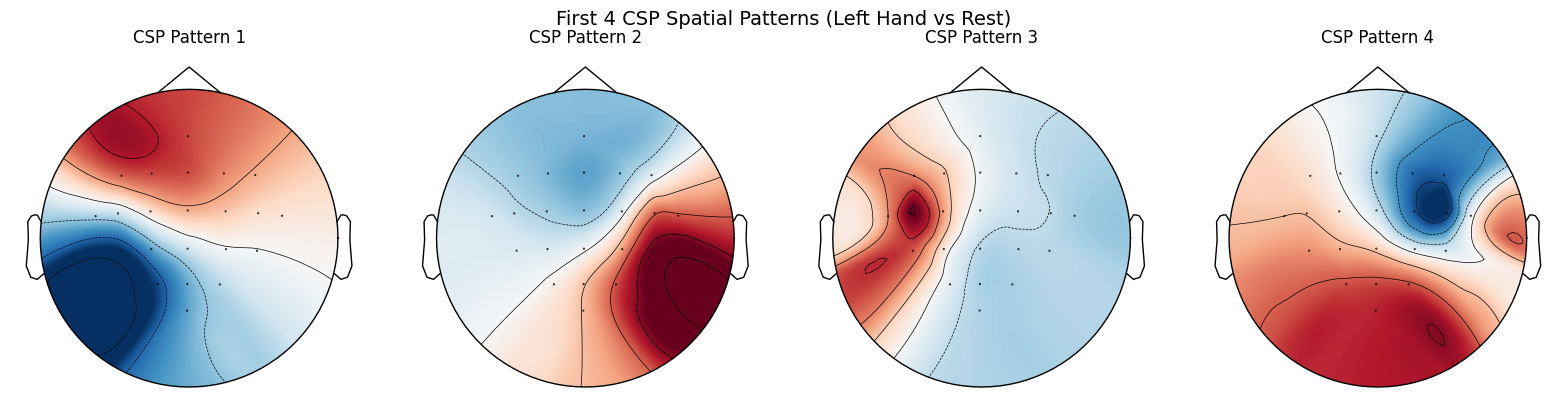

In [17]:
# Visualization: CSP spatial patterns (provided)
# Create an MNE Info object for topographic plotting
info = mne.create_info(ch_names=CH_NAMES_22, sfreq=FS, ch_types='eeg')
montage = mne.channels.make_standard_montage('standard_1020')
info.set_montage(montage)

# Plot first 4 CSP patterns
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
patterns = _csp_obj.patterns_[:4]  # First 4 patterns

for i, (pattern, ax) in enumerate(zip(patterns, axes)):
    mne.viz.plot_topomap(pattern, info, axes=ax, show=False)
    ax.set_title(f'CSP Pattern {i+1}')

fig.suptitle('First 4 CSP Spatial Patterns (Left Hand vs Rest)', fontsize=14)
plt.tight_layout()
plt.show()

> **Decision — CSP components**
>
> 1. Look at the CSP topographic maps. Do any of the patterns show strong weights over the motor cortex (C3/C4 region)? If CSP is working correctly, at least one pattern should resemble the contralateral ERD pattern you saw in Notebook 2.
> 2. We used `n_components=4`. With 4 classes in OVR, that gives 16 total features for ~230 training trials. What is the ratio of features to samples? At what ratio would you start worrying about overfitting?
> 3. If you set `n_components=1`, you'd get only 4 features but lose fine-grained spatial information. If you set `n_components=11` (half of 22 channels), you'd capture almost all variance but likely overfit. Where is the sweet spot and why?
>
> *Write your answers here.*

---
## Part 5 — Sliding Window Segmentation

### Why window the data?

Each epoch is 2 seconds (500 samples). We can increase our effective dataset size by extracting overlapping 1-second windows from each epoch. With a step size of 125 samples (0.5s), a 2-second epoch produces **3 windows** (at offsets 0, 125, 250 samples).

This serves two purposes:
1. **Data augmentation** — 3× more training samples helps small-data classifiers like LDA
2. **Temporal resolution** — each window captures a different moment in the motor imagery period. ERD evolves over the trial; early windows may show onset, late windows may show sustained desynchronization.

### Dimension tracking

Before windowing:
```
X_train shape: (n_train_epochs, 22, 500)     — full 2-second epochs
```

After windowing (window_size=250, step_size=125):
```
X_train shape: (n_train_epochs * 3, 22, 250)  — 1-second windows
y_train shape: (n_train_epochs * 3,)           — labels repeated for each window
```

Each window from the same epoch gets the **same label**. If epoch #42 is class 1 (right hand), all 3 windows from epoch #42 are labeled class 1.

### Why 1-second windows?

The motor imagery ERD signal is strongest in the mu (8–12 Hz) and beta (13–30 Hz) bands. A 1-second window contains 8–12 complete mu-band cycles — enough to estimate band power reliably. Shorter windows (e.g., 0.5s) can't resolve the lower mu frequencies well. Longer windows (e.g., 2s) give fewer samples.

> **Why is windowing especially relevant for real-time BCI?** In a deployed system, you process data in a sliding window — you don't have the luxury of waiting for the full epoch to end before making a prediction. The window size directly determines the system's latency. A 1-second window means the user waits at least 1 second before the BCI responds. For a spelling application, this is acceptable. For a robotic arm, you might need 0.5s windows, accepting worse accuracy for faster response.

---

### Task: Implement `sliding_window()`

```
sliding_window(X, y, window_size=250, step_size=125)

Args:
    X:           np.ndarray, shape (n_epochs, n_channels, n_times)
    y:           np.ndarray, shape (n_epochs,)
    window_size: int, number of samples per window (250 = 1s at 250Hz)
    step_size:   int, step between consecutive windows (125 = 0.5s)

Returns:
    X_windows: np.ndarray, shape (n_windows, n_channels, window_size)
    y_windows: np.ndarray, shape (n_windows,)
```

**Pseudocode:**
1. Initialize empty lists for windows and labels
2. For each epoch `i`:
   - For each start position from 0 to `(n_times - window_size)` inclusive, stepping by `step_size`:
     - Extract `X[i, :, start:start+window_size]` and append to windows list
     - Append `y[i]` to labels list
3. Stack into arrays

In [18]:
def sliding_window(X, y, window_size=250, step_size=125):
    """
    Extract overlapping sliding windows from epochs.
    
    Args:
        X:           np.ndarray, shape (n_epochs, n_channels, n_times)
        y:           np.ndarray, shape (n_epochs,)
        window_size: int, samples per window
        step_size:   int, step between windows
    
    Returns:
        X_windows: np.ndarray, shape (n_windows, n_channels, window_size)
        y_windows: np.ndarray, shape (n_windows,)
    """
    # YOUR CODE HERE
    n_epochs,n_channels,n_times = X.shape
    windows = []
    labels = []

    for i in range(n_epochs):
        for start in range(0,n_times-window_size+1,step_size):
            windows.append(X[i,:,start:start+window_size])
            labels.append(y[i])
    windows,labels = map(np.array,[windows,labels])
    return windows,labels

In [19]:
# Sanity check — sliding_window
_n_times = _X_tr.shape[2]
_window_size = 250
_step_size = 125
_expected_windows_per_epoch = len(range(0, _n_times - _window_size + 1, _step_size))

_X_win, _y_win = sliding_window(_X_tr, _y_tr, _window_size, _step_size)

assert _X_win.shape == (_X_tr.shape[0] * _expected_windows_per_epoch, 22, _window_size), \
    f"Expected shape {(_X_tr.shape[0] * _expected_windows_per_epoch, 22, _window_size)}, got {_X_win.shape}"
assert _X_win.shape[0] == _y_win.shape[0], "Data and labels out of sync"

# Verify label replication: first epoch's windows should all have the same label
assert len(set(_y_win[:_expected_windows_per_epoch])) == 1, \
    "Windows from the same epoch should have the same label"

# Verify window content: first window should match the start of first epoch
assert np.array_equal(_X_win[0], _X_tr[0, :, :_window_size]), \
    "First window should match first epoch's initial segment"

print(f"✓ sliding_window: {_X_tr.shape[0]} epochs → {_X_win.shape[0]} windows")
print(f"  Windows per epoch: {_expected_windows_per_epoch}")
print(f"  Window shape: {_X_win.shape[1:]}")

✓ sliding_window: 229 epochs → 687 windows
  Windows per epoch: 3
  Window shape: (22, 250)


> **Decision — Window parameters**
>
> 1. With `window_size=250` (1s) and `step_size=125` (0.5s), each window overlaps the next by 50%. If you used `step_size=250` (no overlap), how many windows per epoch would you get? What's the trade-off?
> 2. If you set `window_size=125` (0.5s), you'd get more windows but each would have only 4–6 full mu-band cycles. How would this affect the classifier's ability to estimate band power? Would the accuracy go up or down, and why?
> 3. In a real-time BCI, the step size determines how often you update the prediction. `step_size=125` means a new prediction every 0.5s. For a cursor-control BCI, would you want faster or slower updates? What about for a binary yes/no switch?
>
> *Write your answers here.*

---
## Part 6 — Per-Channel Z-Score Normalization

### Why normalize?

EEG amplitude varies dramatically across subjects (due to skull thickness, hair, electrode impedance) and across channels (different brain regions have different baseline activity levels). Without normalization, a classifier might weight high-amplitude channels more heavily simply because their numbers are bigger — not because they carry more discriminative information.

### Z-score normalization

For each channel $c$, we compute:

$$x_{\text{norm}}[c, t] = \frac{x[c, t] - \mu_c}{\sigma_c}$$

where:
- $\mu_c$ — mean of channel $c$ across all timepoints of all **training** windows
- $\sigma_c$ — standard deviation of channel $c$ across all timepoints of all **training** windows
- $x[c, t]$ — voltage at channel $c$, timepoint $t$

After normalization, each channel has mean ≈ 0 and std ≈ 1 on the training set.

### Critical: training statistics only

The $\mu_c$ and $\sigma_c$ must be computed from the **training set only**. These same values are then used to normalize the test set. If you compute statistics on the combined train+test data, information from the test set leaks into the normalization — the model gets a subtle hint about the test data distribution.

In a deployed BCI, this is automatic: you compute statistics during calibration (training), then apply them to all future data. There is no "test set" to accidentally include.

### Dimension tracking

Input: `X_train` shape `(n_windows, 22, 250)`

We compute mean and std per channel:
```
mu shape:    (22,)   — one mean per channel
sigma shape: (22,)   — one std per channel
```

To broadcast correctly, reshape to `(1, 22, 1)` so it divides across the window and time dimensions.

Output: `X_train_norm` shape `(n_windows, 22, 250)` — same shape, normalized values

---

### Task: Implement `compute_normalization_stats()` and `normalize()`

```
compute_normalization_stats(X_train)

Args:
    X_train: np.ndarray, shape (n_windows, n_channels, n_times)

Returns:
    mu:    np.ndarray, shape (n_channels,)
    sigma: np.ndarray, shape (n_channels,)
```

**Pseudocode for `compute_normalization_stats`:**
1. Compute mean across axis 0 (windows) and axis 2 (time) → shape `(n_channels,)`
2. Compute std across the same axes → shape `(n_channels,)`

*Hint:* `np.mean(X, axis=(0, 2))` computes the mean over the first and third axes simultaneously.

```
normalize(X, mu, sigma)

Args:
    X:     np.ndarray, shape (n_windows, n_channels, n_times)
    mu:    np.ndarray, shape (n_channels,)
    sigma: np.ndarray, shape (n_channels,)

Returns:
    X_norm: np.ndarray, shape (n_windows, n_channels, n_times)
```

**Pseudocode for `normalize`:**
1. Reshape `mu` to `(1, n_channels, 1)` for broadcasting
2. Reshape `sigma` to `(1, n_channels, 1)` for broadcasting
3. Return `(X - mu) / sigma`

In [20]:
def compute_normalization_stats(X_train):
    """
    Compute per-channel mean and std from training data.
    
    Args:
        X_train: np.ndarray, shape (n_windows, n_channels, n_times)
    
    Returns:
        mu:    np.ndarray, shape (n_channels,)
        sigma: np.ndarray, shape (n_channels,)
    """
    # YOUR CODE HERE
    mu = np.mean(X_train,axis=(0,2))
    sigma = np.std(X_train,axis =(0,2))
    return mu,sigma


def normalize(X, mu, sigma):
    """
    Apply z-score normalization using precomputed statistics.
    
    Args:
        X:     np.ndarray, shape (n_windows, n_channels, n_times)
        mu:    np.ndarray, shape (n_channels,)
        sigma: np.ndarray, shape (n_channels,)
    
    Returns:
        X_norm: np.ndarray, same shape as X
    """
    # YOUR CODE HERE
    mu = mu.reshape(1,-1,1)
    sigma = sigma.reshape(1,-1,1)
    X = (X-mu)/sigma
    return X

In [21]:
# Sanity check — normalization
_mu, _sigma = compute_normalization_stats(_X_win)

assert _mu.shape == (22,), f"Expected mu shape (22,), got {_mu.shape}"
assert _sigma.shape == (22,), f"Expected sigma shape (22,), got {_sigma.shape}"
assert np.all(_sigma > 0), "All channel stds should be positive"

_X_normed = normalize(_X_win, _mu, _sigma)
assert _X_normed.shape == _X_win.shape, "Shape should not change after normalization"

# After normalization on training data, per-channel mean ≈ 0, std ≈ 1
_ch_means = np.mean(_X_normed, axis=(0, 2))  # (22,)
_ch_stds = np.std(_X_normed, axis=(0, 2))     # (22,)
assert np.allclose(_ch_means, 0, atol=0.01), f"Channel means should be ≈0, got max {np.abs(_ch_means).max():.4f}"
assert np.allclose(_ch_stds, 1, atol=0.01), f"Channel stds should be ≈1, got range [{_ch_stds.min():.4f}, {_ch_stds.max():.4f}]"

print(f"✓ normalization: channel means {_ch_means.mean():.6f}, stds {_ch_stds.mean():.6f}")
print(f"  mu range: [{_mu.min()*1e6:.2f}, {_mu.max()*1e6:.2f}] µV")
print(f"  sigma range: [{_sigma.min()*1e6:.2f}, {_sigma.max()*1e6:.2f}] µV")

✓ normalization: channel means -0.000000, stds 1.000000
  mu range: [-0.03, 0.04] µV
  sigma range: [2.07, 5.00] µV


> **Decision — Normalization strategy**
>
> 1. We normalize per-channel but not per-trial. What would change if we also normalized each trial independently (subtracting the trial mean)? Would this help or hurt for motor imagery classification?
> 2. In a deployed BCI, the normalization statistics are computed during a calibration session. If the user comes back the next day (electrodes re-applied, slightly different positions), should you re-calibrate or use yesterday's statistics? What about the CSP filters?
> 3. Some papers normalize before CSP, others after. We apply CSP to the raw filtered data and normalize the windowed output. What changes if you normalize before CSP? Think about what CSP is optimizing (variance ratios).
>
> *Write your answers here.*

---
## Part 7 — The Complete Pipeline: `run_pipeline()`

### Putting it all together

Now we assemble every piece into a single function. This is the entry point for all future notebooks. The pipeline flow is:

```
load_subject_epochs()      — GDF → epochs + labels
    ↓
reject_artifacts()         — remove contaminated trials
    ↓
split_epochs()             — stratified train/test split (BEFORE windowing)
    ↓
sliding_window()           — extract overlapping 1s windows (train and test SEPARATELY)
    ↓
compute_normalization_stats() + normalize()  — z-score using TRAINING stats only
    ↓
Returns: X_train, X_test, y_train, y_test
```

**Note on CSP:** CSP is *not* included in `run_pipeline()`. This is intentional. CSP produces features for classical classifiers (LDA, SVM) but deep learning models (EEGNet, Conformer) work on the raw windowed data. By leaving CSP out of the pipeline, we keep `run_pipeline()` universal — it returns windowed, normalized EEG data that any downstream model can consume. The CSP+classifier pipeline in Notebook 4 will call `fit_csp()` as a separate step after `run_pipeline()`.

### Output shapes

For a typical subject with ~270 clean trials (after artifact rejection), 80/20 split:
```
X_train: (n_train_windows, 22, 250)   — e.g. (648, 22, 250) with 216 epochs × 3 windows
X_test:  (n_test_windows, 22, 250)    — e.g. (162, 22, 250) with 54 epochs × 3 windows
y_train: (n_train_windows,)            — e.g. (648,)
y_test:  (n_test_windows,)             — e.g. (162,)
```

---

### Task: Implement `run_pipeline()`

```
run_pipeline(subject_id, data_dir, session='T', artifact_threshold=100.0,
             test_size=0.2, window_size=250, step_size=125, random_state=42)

Args:
    subject_id:          str, e.g. 'A01'
    data_dir:            str, path to data directory
    session:             str, 'T' or 'E'
    artifact_threshold:  float, PTP threshold in µV
    test_size:           float, fraction for test set
    window_size:         int, window length in samples
    step_size:           int, step between windows in samples
    random_state:        int, for reproducibility

Returns:
    dict with keys:
        'X_train': np.ndarray, shape (n_train_windows, n_channels, window_size)
        'X_test':  np.ndarray, shape (n_test_windows, n_channels, window_size)
        'y_train': np.ndarray, shape (n_train_windows,)
        'y_test':  np.ndarray, shape (n_test_windows,)
        'n_rejected': int, number of artifact-rejected trials
        'mu':      np.ndarray, normalization means (for later use)
        'sigma':   np.ndarray, normalization stds (for later use)
```

**Pseudocode:**
1. Load epochs with `load_subject_epochs()`
2. Reject artifacts with `reject_artifacts()`
3. Split at epoch level with `split_epochs()`
4. Apply sliding windows to train and test **separately**
5. Compute normalization stats from **training windows only**
6. Normalize both train and test with training stats
7. Return results dict

In [22]:
def run_pipeline(subject_id, data_dir, session='T', artifact_threshold=100.0,
                 test_size=0.2, window_size=250, step_size=125, random_state=42):
    """
    Complete preprocessing pipeline: load → reject → split → window → normalize.
    
    Args:
        subject_id:          str, e.g. 'A01'
        data_dir:            str, path to data directory
        session:             str, 'T' or 'E'
        artifact_threshold:  float, PTP threshold in µV
        test_size:           float, fraction for test set
        window_size:         int, samples per window
        step_size:           int, step between windows
        random_state:        int, random seed
    
    Returns:
        dict with 'X_train', 'X_test', 'y_train', 'y_test',
             'n_rejected', 'mu', 'sigma'
    """
    # YOUR CODE HERE
    data, labels = load_subject_epochs(subject_id, data_dir, session)
    clean_data,clean_labels,n_rejected = reject_artifacts(data,labels,threshold_uv=artifact_threshold)
    X_train, X_test, y_train, y_test = split_epochs(clean_data,clean_labels,test_size=test_size,random_state=random_state)
    train_windows, train_labels = sliding_window(X_train,y_train,window_size=window_size,step_size=step_size)
    test_windows,test_labels = sliding_window(X_test,y_test,window_size=window_size,step_size=step_size)
    mu,sigma = compute_normalization_stats(train_windows)
    X_fin_train = normalize(train_windows,mu,sigma)
    X_fin_test = normalize(test_windows,mu,sigma)
    return {'X_train':X_fin_train, 'X_test':X_fin_test, 'y_train':train_labels, 'y_test':test_labels,
             'n_rejected':n_rejected, 'mu':mu, 'sigma':sigma}
    

In [23]:
# Sanity check — run_pipeline (full integration test)
_result = run_pipeline('A01', DATA_DIR)

# Check all keys present
_required_keys = {'X_train', 'X_test', 'y_train', 'y_test', 'n_rejected', 'mu', 'sigma'}
assert _required_keys.issubset(_result.keys()), f"Missing keys: {_required_keys - _result.keys()}"

# Check shapes
assert _result['X_train'].ndim == 3, f"X_train should be 3D, got {_result['X_train'].ndim}D"
assert _result['X_train'].shape[1] == 22, f"Expected 22 channels, got {_result['X_train'].shape[1]}"
assert _result['X_train'].shape[2] == 250, f"Expected 250 timepoints, got {_result['X_train'].shape[2]}"
assert _result['X_train'].shape[0] == _result['y_train'].shape[0], "Train data/labels mismatch"
assert _result['X_test'].shape[0] == _result['y_test'].shape[0], "Test data/labels mismatch"

# Check normalization was applied (training data should have mean ≈ 0, std ≈ 1 per channel)
_ch_means = np.mean(_result['X_train'], axis=(0, 2))
_ch_stds = np.std(_result['X_train'], axis=(0, 2))
assert np.allclose(_ch_means, 0, atol=0.01), "Training data should be normalized (mean ≈ 0)"
assert np.allclose(_ch_stds, 1, atol=0.01), "Training data should be normalized (std ≈ 1)"

# Check that test data is NOT independently normalized
# (test stats won't be exactly 0/1 since we used training stats)
_test_ch_means = np.mean(_result['X_test'], axis=(0, 2))
_test_ch_stds = np.std(_result['X_test'], axis=(0, 2))
# They should be close but not exactly 0/1
print(f"  Test data channel mean range: [{_test_ch_means.min():.3f}, {_test_ch_means.max():.3f}]")
print(f"  Test data channel std range: [{_test_ch_stds.min():.3f}, {_test_ch_stds.max():.3f}]")

# Check label values
assert set(np.unique(_result['y_train'])).issubset({0, 1, 2, 3}), "Labels should be in {0,1,2,3}"

print(f"\n✓ run_pipeline complete for A01:")
print(f"  X_train: {_result['X_train'].shape}")
print(f"  X_test:  {_result['X_test'].shape}")
print(f"  y_train: {_result['y_train'].shape}, classes: {np.bincount(_result['y_train'])}")
print(f"  y_test:  {_result['y_test'].shape}, classes: {np.bincount(_result['y_test'])}")
print(f"  Rejected: {_result['n_rejected']} trials")

  A01T: 288 epochs, shape (288, 22, 501), class dist: [72 72 72 72]
  Test data channel mean range: [-0.016, 0.008]
  Test data channel std range: [0.954, 1.019]

✓ run_pipeline complete for A01:
  X_train: (690, 22, 250)
  X_test:  (174, 22, 250)
  y_train: (690,), classes: [171 174 171 174]
  y_test:  (174,), classes: [45 42 45 42]
  Rejected: 0 trials


---
## Part 8 — Pipeline Validation: All 9 Subjects

A pipeline that works on one subject might break on another (different artifact rates, edge cases in label alignment). Let's validate on all 9 subjects and inspect the statistics.

In [24]:
# Run pipeline on all 9 subjects (provided)
all_results = {}
print("Running pipeline on all subjects...\n")

for i in range(1, 10):
    subj = f'A0{i}'
    try:
        result = run_pipeline(subj, DATA_DIR)
        all_results[subj] = result
        print(f"  {subj}: train={result['X_train'].shape[0]:>4d} windows, "
              f"test={result['X_test'].shape[0]:>4d} windows, "
              f"rejected={result['n_rejected']:>3d} trials")
    except Exception as e:
        print(f"  {subj}: FAILED — {e}")

print(f"\nSuccessfully processed {len(all_results)}/9 subjects")

Running pipeline on all subjects...

  A01T: 288 epochs, shape (288, 22, 501), class dist: [72 72 72 72]
  A01: train= 690 windows, test= 174 windows, rejected=  0 trials
  A02T: 288 epochs, shape (288, 22, 501), class dist: [72 72 72 72]
  A02: train= 690 windows, test= 174 windows, rejected=  0 trials
  A03T: 288 epochs, shape (288, 22, 501), class dist: [72 72 72 72]
  A03: train= 690 windows, test= 174 windows, rejected=  0 trials
  A04T: 288 epochs, shape (288, 22, 501), class dist: [72 72 72 72]
  A04: train= 690 windows, test= 174 windows, rejected=  0 trials
  A05T: 288 epochs, shape (288, 22, 501), class dist: [72 72 72 72]
  A05: train= 690 windows, test= 174 windows, rejected=  0 trials
  A06T: 288 epochs, shape (288, 22, 501), class dist: [72 72 72 72]
  A06: train= 687 windows, test= 174 windows, rejected=  1 trials
  A07T: 288 epochs, shape (288, 22, 501), class dist: [72 72 72 72]
  A07: train= 690 windows, test= 174 windows, rejected=  0 trials
  A08T: 288 epochs, shape

In [25]:
# Sanity check — all 9 subjects processed
assert len(all_results) == 9, f"Expected 9 subjects, got {len(all_results)}"

for _subj, _res in all_results.items():
    assert _res['X_train'].shape[1] == 22, f"{_subj}: wrong channel count"
    assert _res['X_train'].shape[2] == 250, f"{_subj}: wrong window size"
    assert _res['X_train'].shape[0] > 100, f"{_subj}: suspiciously few training windows"

print("✓ All 9 subjects passed validation")

✓ All 9 subjects passed validation


### Visualize: cross-subject statistics

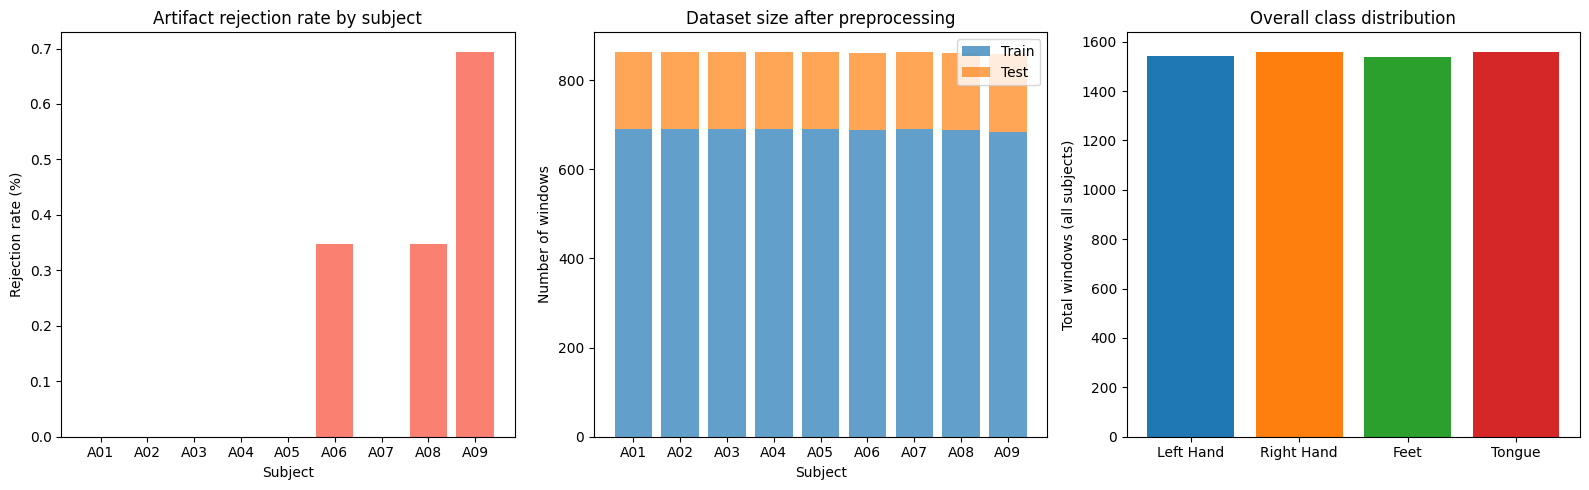

In [26]:
# Visualization: cross-subject pipeline statistics (provided)
subjects = sorted(all_results.keys())

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1. Artifact rejection rates
rejection_rates = [all_results[s]['n_rejected'] for s in subjects]
total_trials = [all_results[s]['X_train'].shape[0] // 3 + 
                all_results[s]['X_test'].shape[0] // 3 + 
                all_results[s]['n_rejected'] for s in subjects]  # approximate
rej_pct = [100 * r / t for r, t in zip(rejection_rates, total_trials)]
axes[0].bar(subjects, rej_pct, color='salmon')
axes[0].set_ylabel('Rejection rate (%)')
axes[0].set_title('Artifact rejection rate by subject')
axes[0].set_xlabel('Subject')

# 2. Training set sizes
train_sizes = [all_results[s]['X_train'].shape[0] for s in subjects]
test_sizes = [all_results[s]['X_test'].shape[0] for s in subjects]
axes[1].bar(subjects, train_sizes, label='Train', alpha=0.7)
axes[1].bar(subjects, test_sizes, bottom=train_sizes, label='Test', alpha=0.7)
axes[1].set_ylabel('Number of windows')
axes[1].set_title('Dataset size after preprocessing')
axes[1].set_xlabel('Subject')
axes[1].legend()

# 3. Class balance (aggregate across subjects)
all_train_labels = np.concatenate([all_results[s]['y_train'] for s in subjects])
class_counts = np.bincount(all_train_labels)
class_names = ['Left Hand', 'Right Hand', 'Feet', 'Tongue']
axes[2].bar(class_names, class_counts, color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'])
axes[2].set_ylabel('Total windows (all subjects)')
axes[2].set_title('Overall class distribution')

plt.tight_layout()
plt.show()

> **Decision — Cross-subject variation**
>
> 1. Which subject has the highest artifact rejection rate? What might this tell you about that subject's recording session (movement, electrode quality, attention)?
> 2. The class distribution is approximately balanced, but after artifact rejection some classes may have slightly fewer samples. How would this affect a classifier that uses accuracy as its metric? (This is why Notebook 4 will introduce Cohen's kappa.)
> 3. Subject-to-subject variation in data quality is a major challenge for deployed BCIs. If you were building a consumer BCI product, would you ship a "universal" model or require per-user calibration? What does the variation you see here suggest?
>
> *Write your answers here.*

---
## Part 9 — Ablation: Effect of Preprocessing Choices

To understand whether each preprocessing step actually matters, let's run a quick experiment. We'll use a simple classifier (Logistic Regression on CSP features) to measure the effect of each step.

This is a preview of the CSP+classifier pipeline from Notebook 4 — don't worry about understanding LDA/SVM yet. The point here is to see whether preprocessing choices *change the numbers*.

### Hypothesis

Before running the experiments, predict the outcome:

> **Hypothesis 1 — Artifact rejection:** Removing artifact-contaminated trials should ___ (increase/decrease) accuracy because ___.
>
> **Hypothesis 2 — Normalization:** Adding per-channel normalization should ___ (increase/decrease/not change) accuracy because ___.
>
> **Hypothesis 3 — Data leakage:** Splitting *after* windowing (the wrong way) should ___ (increase/decrease) apparent accuracy compared to splitting *before* windowing (the correct way), because ___.
>
> *Write your predictions here before running the next cell.*

In [27]:
# Ablation experiment (provided — just run it)
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

def quick_csp_classify(X_train, y_train, X_test, y_test, n_components=4):
    """CSP + Logistic Regression — quick accuracy estimate."""
    csp = CSP(n_components=n_components, log=True)
    X_tr_csp = csp.fit_transform(X_train, y_train)
    X_te_csp = csp.transform(X_test)
    clf = LogisticRegression(max_iter=1000, random_state=42)
    clf.fit(X_tr_csp, y_train)
    return accuracy_score(y_test, clf.predict(X_te_csp))

# Use subject A01 for ablation
subj = 'A01'
epochs_data, labels = load_subject_epochs(subj, DATA_DIR, session='T')

# --- Condition 1: Full pipeline (correct) ---
result_full = run_pipeline(subj, DATA_DIR)
acc_full = quick_csp_classify(
    result_full['X_train'], result_full['y_train'],
    result_full['X_test'], result_full['y_test']
)

# --- Condition 2: No artifact rejection ---
X_tr_norej, X_te_norej, y_tr_norej, y_te_norej = split_epochs(epochs_data, labels)
X_tr_norej_w, y_tr_norej_w = sliding_window(X_tr_norej, y_tr_norej)
X_te_norej_w, y_te_norej_w = sliding_window(X_te_norej, y_te_norej)
mu_norej, sigma_norej = compute_normalization_stats(X_tr_norej_w)
X_tr_norej_n = normalize(X_tr_norej_w, mu_norej, sigma_norej)
X_te_norej_n = normalize(X_te_norej_w, mu_norej, sigma_norej)
acc_norej = quick_csp_classify(X_tr_norej_n, y_tr_norej_w, X_te_norej_n, y_te_norej_w)

# --- Condition 3: No normalization ---
clean_data, clean_labels, _ = reject_artifacts(epochs_data, labels)
X_tr_nonorm, X_te_nonorm, y_tr_nonorm, y_te_nonorm = split_epochs(clean_data, clean_labels)
X_tr_nonorm_w, y_tr_nonorm_w = sliding_window(X_tr_nonorm, y_tr_nonorm)
X_te_nonorm_w, y_te_nonorm_w = sliding_window(X_te_nonorm, y_te_nonorm)
# Skip normalization
acc_nonorm = quick_csp_classify(X_tr_nonorm_w, y_tr_nonorm_w, X_te_nonorm_w, y_te_nonorm_w)

# --- Condition 4: WRONG — split AFTER windowing (data leakage) ---
clean_data_leak, clean_labels_leak, _ = reject_artifacts(epochs_data, labels)
# Window ALL data first (wrong!)
X_all_w, y_all_w = sliding_window(clean_data_leak, clean_labels_leak)
mu_leak, sigma_leak = compute_normalization_stats(X_all_w)
X_all_n = normalize(X_all_w, mu_leak, sigma_leak)
# THEN split (windows from same epoch can end up in train and test)
sss_leak = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
tr_idx, te_idx = next(sss_leak.split(X_all_n, y_all_w))
acc_leak = quick_csp_classify(X_all_n[tr_idx], y_all_w[tr_idx], X_all_n[te_idx], y_all_w[te_idx])

print("\n" + "="*60)
print("ABLATION RESULTS — Subject A01")
print("="*60)
print(f"  Full pipeline (correct):        {acc_full:.3f}")
print(f"  No artifact rejection:          {acc_norej:.3f}")
print(f"  No normalization:               {acc_nonorm:.3f}")
print(f"  WRONG: split after windowing:   {acc_leak:.3f}  ← data leakage!")
print("="*60)

  A01T: 288 epochs, shape (288, 22, 501), class dist: [72 72 72 72]
  A01T: 288 epochs, shape (288, 22, 501), class dist: [72 72 72 72]

ABLATION RESULTS — Subject A01
  Full pipeline (correct):        0.603
  No artifact rejection:          0.603
  No normalization:               0.603
  WRONG: split after windowing:   0.688  ← data leakage!


### Observation

> **Ablation results for Subject A01:**
>
> - Full pipeline accuracy: ____%
> - Without artifact rejection: ____%  (difference: ___ pp). This confirms that artifact rejection ___ because ___.
> - Without normalization: ____%  (difference: ___ pp). This suggests that normalization ___ for CSP features because ___.
> - With data leakage (wrong split): ____%  (difference: ___ pp). The inflated accuracy from data leakage is ___ percentage points higher. This is a ___ (small/dangerous) amount because ___.
>
> The most impactful preprocessing step for this subject was ___ because ___.
> The data leakage result is particularly concerning because in a published paper, this would make the model appear ___ than it actually is, leading readers to ___.
>
> *Fill in your observations.*

---
## Summary

You've built a complete EEG preprocessing pipeline that:

1. **Detects and rejects artifacts** using peak-to-peak thresholding, keeping data and labels aligned
2. **Splits at the epoch level** before any windowing, preventing data leakage
3. **Applies CSP spatial filtering** (as a separate step for classical classifiers) using MNE's implementation, fit on training data only
4. **Extracts overlapping sliding windows** to increase effective sample size
5. **Normalizes per-channel** using training statistics only

The `run_pipeline()` function encapsulates steps 1, 2, 4, and 5 into a single call that returns classifier-ready data. Every subsequent notebook starts here.

### Key design decisions and their rationale

| Decision | Choice | Why |
|---|---|---|
| Artifact method | Peak-to-peak | Robust to DC drift; simple; works in real-time |
| Artifact threshold | 100 µV | ~2× expected EEG amplitude after 4–38 Hz filtering |
| Split strategy | Epoch-level, before windowing | Prevents data leakage from overlapping windows |
| Window size | 1s (250 samples) | Enough for mu-band estimation; maps to real-time latency |
| Window overlap | 50% (step=125) | 3× data augmentation without excessive redundancy |
| Normalization | Per-channel z-score | Handles cross-channel and cross-subject amplitude differences |
| CSP placement | Outside pipeline | Deep learning models don't need CSP; keep pipeline universal |

### What's next

In **Notebook 4 (CSP + LDA/SVM)**, you'll use `run_pipeline()` and `fit_csp()` to build a complete classical BCI classifier. You'll implement LDA from the ground up, understand why it works well with CSP features, and produce benchmark numbers comparable to the published literature on Dataset 2a.